# Voisins Piezos 

Recherche de Piezos proche géographiquement et/ou appartenant à la même couche géologique.

Upload de catalogue pizeo depuis la database de BQ.

## 0. Params et Setup

In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import os
import pandas as pd
from google.cloud import bigquery

from hydrosense.params import *

## 2. TesT du chargement des données

Les informations stockées dans le fichier .env et qui sont mise à disposition grâce au module params.py

In [51]:
TABLE = "cat_piezo_interm"
GCP_PROJECT_ID,BQ_DATASET_ID,TABLE
MIN_COMPLETUDE = 0.8

bss_id = 'BSS001QHYH' # target of the day !
bss_id = TARGETS_BSS[10]
print(bss_id)

client = bigquery.Client(project=GCP_PROJECT_ID)

BSS001VAJT


In [52]:
query = f"""
            SELECT *
            FROM `{GCP_PROJECT_ID}.{BQ_DATASET_ID}.{TABLE}`
            WHERE taux_completude > {MIN_COMPLETUDE}
        """
try:
    query_job = client.query(query)
    result = query_job.result()
    cat_clean = result.to_dataframe()
except:
    print("Not uploaded from Big Query")

/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 2.1 Isoler le code BDLisa et masse_eau du piezo target.

In [53]:
%reload_ext autoreload
from hydrosense.utils.geo import calc_dist, a_une_couche_commune

target_row = cat_clean[cat_clean['bss_id'] == bss_id]


set_eau_target = extraire_set(target_row['codes_masse_eau_edl'].values[0])
set_geo_target = extraire_set(target_row['codes_bdlisa'].values[0])

lat_target, lon_target = target_row['y'].values[0], target_row['x'].values[0]

print(f"🎯 Target {bss_id}")
print(f"   - Masse d'eau : {set_eau_target}")
print(f"   - BD Lisa     : {set_geo_target}")


🎯 Target BSS001VAJT
   - Masse d'eau : {'FG075A'}
   - BD Lisa     : {'348AE04'}


#### 2.2 Fonction intersection géologique

In [66]:
from hydrosense.utils.geo import trouver_voisins_hydrogeologiques
from hydrosense.database.bigquery import info_piezo
bss_id = "BSS001QHYH" # Votre target

# Appel de la fonction de preprocessing
top_10 = trouver_voisins_hydrogeologiques(df_catalogue=cat_clean, bss_target=bss_id, n_voisins=10)
print(top_10[['bss_id', 'distance_km', 'same_eau', 'same_geo']])

          bss_id  distance_km  same_eau  same_geo
2010  BSS001QHPU     7.686971      True      True
2012  BSS001QJMK     9.853626      True      True
423   BSS001QGLU    16.925575      True      True
2013  BSS001QJSX    18.795035      True      True
420   BSS001QGLS    19.440282      True      True
422   BSS001QHHN    33.168654      True      True
421   BSS001QEVT    56.372222      True      True
321   BSS001RMFT    23.041868     False      True
304   BSS001QJUZ    23.878520     False      True
300   BSS001RMZT    29.732116     False      True


### 2.3 Compter le nb de voisins pour tout les piezos de notre liste de piezometres.

In [1]:
# for bss in TARGETS_BSS[:]:
#     print(info_piezo(bss)['code_departement'].values )


In [55]:

for bss in TARGETS_BSS[:]:
    top_10 = trouver_voisins_hydrogeologiques(df_catalogue=cat_clean, bss_target=bss, n_voisins=10)
    print(top_10[['bss_id', 'distance_km', 'same_eau', 'same_geo']])


          bss_id  distance_km  same_eau  same_geo
2069  BSS002DETB    10.945533      True      True
          bss_id  distance_km  same_eau  same_geo
1262  BSS001DJDP    30.913957      True      True
1022  BSS001BLWA    13.829771     False      True
1018  BSS000XNZX    18.328699     False      True
1019  BSS000ZQXN    51.000267     False      True
1021  BSS000XTEY    58.592940     False      True
          bss_id  distance_km  same_eau  same_geo
1021  BSS000XTEY    29.965827      True      True
1018  BSS000XNZX    49.795426      True      True
1022  BSS001BLWA    54.502808      True      True
1017  BSS001BLSZ    26.469878      True     False
1016  BSS000XMZQ    50.607850      True     False
1245  BSS001DKCW    50.750087      True     False
1020  BSS000XLMM    90.065898      True     False
1556  BSS001BJPJ    93.182246      True     False
1023  BSS000ZLVF   103.937889      True     False
1557  BSS001DHAJ   104.547359      True     False
          bss_id  distance_km  same_eau  same_geo


### Process de creation des mutli-piezo

Pour l'instant le piezo target n'a pas été téléchargé.
Les fonctions de base peuvent le télécharger sous la forme classique.

In [56]:
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense.database.bigquery import load_piezo_bq

import matplotlib.pyplot as plt

          bss_id  distance_km  same_eau  same_geo
2069  BSS002DETB    10.945533      True      True
BSS002DETB : 9351 lignes chargées
Trou de 67 jours détecté ! 3880 lignes supprimées.
DataFrame final : 2011-04-21 00:00:00 → 2026-05-30 00:00:00 | 5519 jours
          bss_id  distance_km  same_eau  same_geo
1262  BSS001DJDP    30.913957      True      True
1022  BSS001BLWA    13.829771     False      True
1018  BSS000XNZX    18.328699     False      True
1019  BSS000ZQXN    51.000267     False      True
1021  BSS000XTEY    58.592940     False      True
BSS001DJDP : 7186 lignes chargées
Trou de 54 jours détecté ! 7138 lignes supprimées.
DataFrame final : 2026-04-10 00:00:00 → 2026-05-27 00:00:00 | 48 jours
BSS001BLWA : 7706 lignes chargées
Trou de 84 jours détecté ! 1310 lignes supprimées.
DataFrame final : 2008-09-09 00:00:00 → 2026-05-29 00:00:00 | 6472 jours
BSS000XNZX : 8135 lignes chargées
Trou de 61 jours détecté ! 1669 lignes supprimées.
DataFrame final : 2008-09-15 00:00:00 → 202

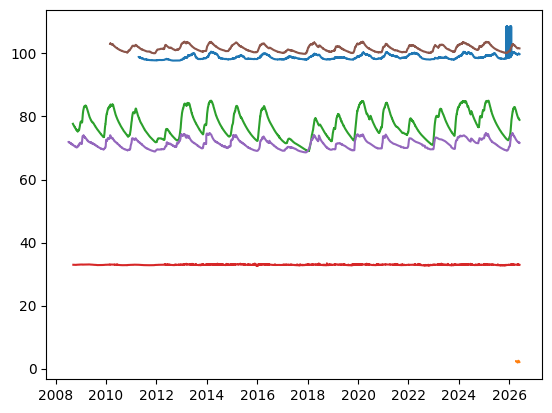

In [57]:
for bss in TARGETS_BSS[:2]:
    top_10 = trouver_voisins_hydrogeologiques(df_catalogue=cat_clean, bss_target=bss, n_voisins=10)
    print(top_10[['bss_id', 'distance_km', 'same_eau', 'same_geo']])

    for id in top_10['bss_id'].values:
        df_voisin = clean_piezo(load_piezo_bq(bss_id = id ))
        plt.plot(df_voisin['date_mesure'],df_voisin['niveau_nappe_eau'])

plt.show()

In [58]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer  # Requis pour activer IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("🔄 Récupération et alignement des voisins...")
series_list = []

# 1. ALIGNEMENT TEMPOREL
for id in top_10['bss_id'].values:
    df_voisin = clean_piezo(load_piezo_bq(bss_id=id))
    df_voisin['date_mesure'] = pd.to_datetime(df_voisin['date_mesure']).dt.normalize()

    # On indexe par la date et on isole la chronique, renommée avec le code BSS
    s_voisin = df_voisin.set_index('date_mesure')['niveau_nappe_eau'].rename(id)
    series_list.append(s_voisin)


🔄 Récupération et alignement des voisins...
BSS001DJDP : 7186 lignes chargées
Trou de 54 jours détecté ! 7138 lignes supprimées.
DataFrame final : 2026-04-10 00:00:00 → 2026-05-27 00:00:00 | 48 jours
BSS001BLWA : 7706 lignes chargées
Trou de 84 jours détecté ! 1310 lignes supprimées.
DataFrame final : 2008-09-09 00:00:00 → 2026-05-29 00:00:00 | 6472 jours
BSS000XNZX : 8135 lignes chargées
Trou de 61 jours détecté ! 1669 lignes supprimées.
DataFrame final : 2008-09-15 00:00:00 → 2026-05-29 00:00:00 | 6466 jours
BSS000ZQXN : 7682 lignes chargées
Trou de 62 jours détecté ! 1176 lignes supprimées.
DataFrame final : 2008-07-09 00:00:00 → 2026-05-29 00:00:00 | 6534 jours
BSS000XTEY : 7226 lignes chargées
Trou de 53 jours détecté ! 1392 lignes supprimées.
DataFrame final : 2010-03-02 00:00:00 → 2026-05-29 00:00:00 | 5933 jours


In [59]:
top_10

,altitude_station,bss_id,code_departement,codes_bdlisa,codes_masse_eau_edl,date_debut_mesure,date_fin_mesure,nb_mesures_piezo,nom_commune,profondeur_investigation,...,taux_completude,p95_global,p85_global,p50_global,p20_global,p10_global,p5_global,same_eau,same_geo,distance_km
1262,3.5,BSS001DJDP,44,938AC01,GG115,2006-01-11 00:00:00+00:00,2026-05-27 00:00:00+00:00,7186,Massérac,10.5,...,96.56,NaN,NaN,NaN,NaN,NaN,NaN,True,True,30.913957
1022,88.0,BSS001BLWA,35,174AA01,GG015,2004-11-16 00:00:00+00:00,2026-05-27 00:00:00+00:00,7704,La Noë-Blanche,37.0,...,97.98,NaN,NaN,NaN,NaN,NaN,NaN,False,True,13.829771
1018,35.0,BSS000XNZX,35,174AA01,GG015,2003-12-05 00:00:00+00:00,2026-05-27 00:00:00+00:00,8133,Saint-Jacques-de-la-Lande,60.0,...,99.06,NaN,NaN,NaN,NaN,NaN,NaN,False,True,18.328699
1019,75.0,BSS000ZQXN,35,174AA01,GG015,2005-02-18 00:00:00+00:00,2026-05-28 00:00:00+00:00,7681,Arbrissel,28.0,...,98.85,NaN,NaN,NaN,NaN,NaN,NaN,False,True,51.000267
1021,107.0,BSS000XTEY,35,174AA01,GG015,2006-01-25 00:00:00+00:00,2026-05-27 00:00:00+00:00,7224,Val-d'Izé,28.0,...,97.25,NaN,NaN,NaN,NaN,NaN,NaN,False,True,58.592940


🔄 Récupération et alignement des voisins...
BSS001DJDP : 7186 lignes chargées
Trou de 54 jours détecté ! 7138 lignes supprimées.
DataFrame final : 2026-04-10 00:00:00 → 2026-05-27 00:00:00 | 48 jours
BSS001BLWA : 7706 lignes chargées
Trou de 84 jours détecté ! 1310 lignes supprimées.
DataFrame final : 2008-09-09 00:00:00 → 2026-05-29 00:00:00 | 6472 jours
BSS000XNZX : 8135 lignes chargées
Trou de 61 jours détecté ! 1669 lignes supprimées.
DataFrame final : 2008-09-15 00:00:00 → 2026-05-29 00:00:00 | 6466 jours
BSS000ZQXN : 7682 lignes chargées
Trou de 62 jours détecté ! 1176 lignes supprimées.
DataFrame final : 2008-07-09 00:00:00 → 2026-05-29 00:00:00 | 6534 jours
BSS000XTEY : 7226 lignes chargées
Trou de 53 jours détecté ! 1392 lignes supprimées.
DataFrame final : 2010-03-02 00:00:00 → 2026-05-29 00:00:00 | 5933 jours
📊 Dimensions de la matrice fusionnée : (6534, 5)
⚠️ Pourcentage de valeurs manquantes (brut) : 22.1%
🧠 Imputation intelligente des trous...
🌊 Application du lissage (Mo

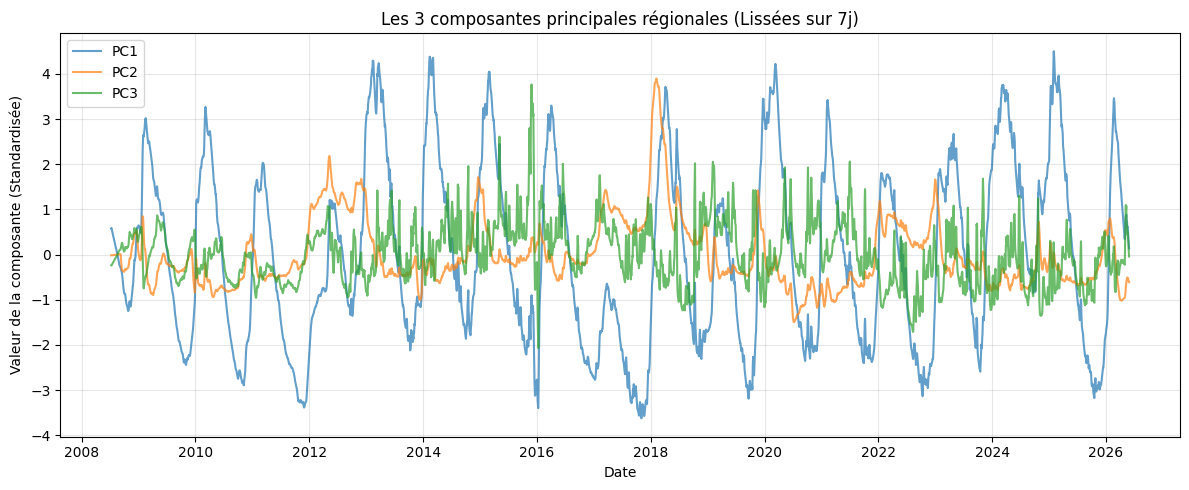

In [60]:
from hydrosense.preprocess.features import extraire_PCA_piezo

df_pca = extraire_PCA_piezo(
    voisins_ids=top_10['bss_id'],
    n_components=3,
    toggle_plot=True
)

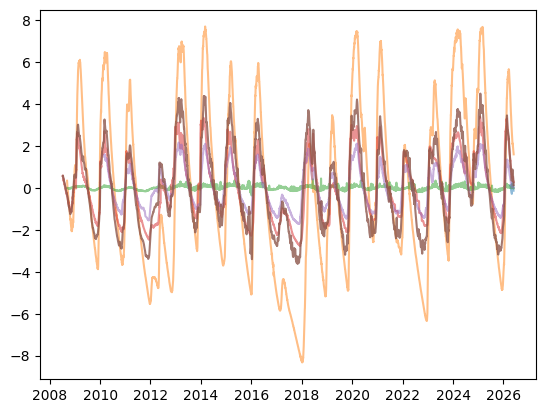

In [61]:
for voisin in series_list:
    s = voisin - voisin.mean()
    plt.plot(s, alpha= 0.5)

plt.plot(df_pca.index, df_pca['PC1'], label='PC1', alpha=0.8)

plt.show()


In [62]:
df_pca.var(axis = 0), pca.explained_variance_

(PC1    3.929388
 PC2    0.579333
 PC3    0.428189
 dtype: float64,
 array([3.86485379, 0.58146217, 0.48773717]))

BSS000ZPHJ : 7423 lignes chargées
DataFrame final : 2005-12-22 00:00:00 → 2026-05-29 00:00:00 | 7464 jours


<Axes: xlabel='PC1', ylabel='niveau_nappe_eau'>

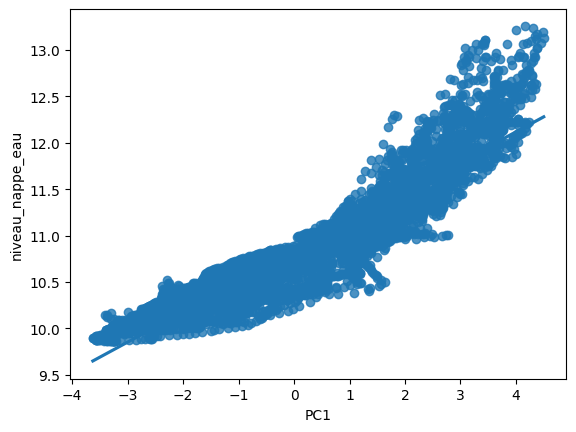

In [64]:
df_clean = clean_piezo(load_piezo_bq(bss))
df_comp = df_clean.merge(df_pca, how='left', on='date_mesure')

df_comp

import seaborn as sns
sns.regplot(data = df_comp, x = 'PC1', y = 'niveau_nappe_eau')


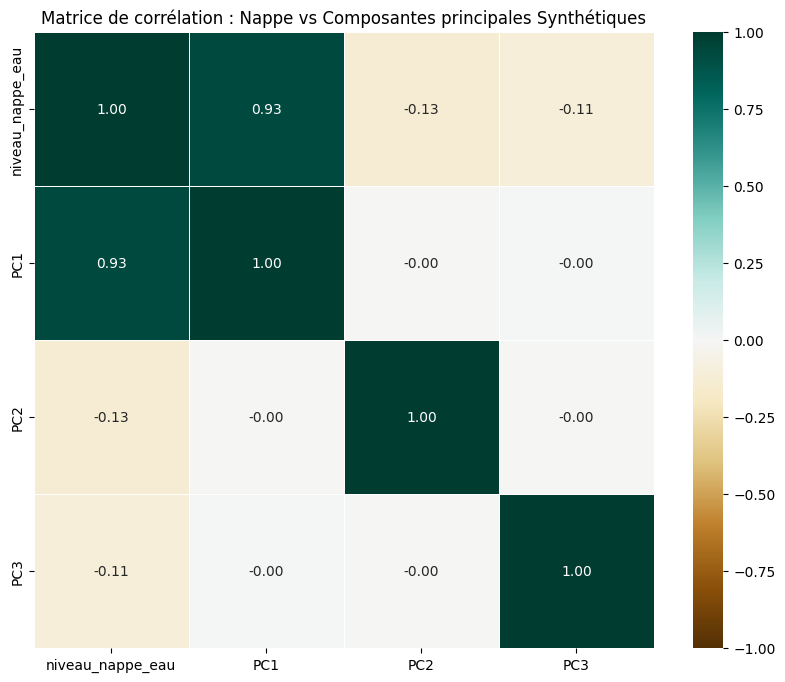

In [65]:
cols_to_corr = ['niveau_nappe_eau', 'PC1', 'PC2','PC3']
corr_mat = df_comp[cols_to_corr].corr()

plt.figure(figsize=(10, 8))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Composantes principales Synthétiques")
plt.show()